## Construindo a primeira rede neural

Utilizando tensorflow keras para criar e ententer como uma rede neural funciona

### Importando Biblioteca KERAS

In [ ]:
import tensorflow
from tensorflow import keras

### Extraindo informações sobre o dataset

In [ ]:
# Carregando Dataset Fashion Mnist
dataset = keras.datasets.fashion_mnist

((train_imgs, train_labels),(test_imgs, test_labels))= dataset.load_data()


print(len(train_imgs)) # tamanho conjunto de treino
print(len(test_imgs)) # tamanho conjunto de teste

print(train_imgs.shape) # tamanho, dimensões das imagens
print(test_imgs.shape) # tamanho, dimensões das imagens

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000
10000
(60000, 28, 28)
(10000, 28, 28)


## Vizualização do conjunto de dados

### Importando matplotlib para mostrar gráficos

In [ ]:
import matplotlib.pyplot as plt

### Print Imagem + Label do Dataset

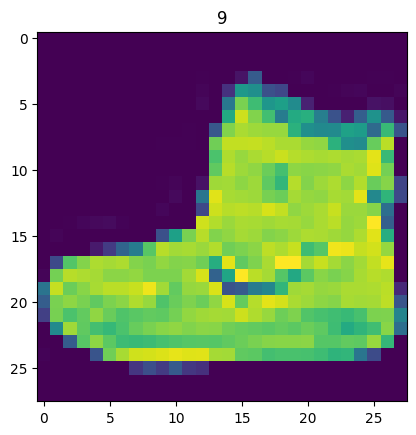

In [ ]:
plt.imshow(train_imgs[0]) # troque '0' pela posição da imagem que deseja ver
plt.title(train_labels[0]) # troque '0' pela posição da label que deseja ver
plt.show()

### Mapeando as o número das classes para texto em pt-br
> possível pegar no github https://github.com/zalandoresearch/fashion-mnist

In [ ]:
classes_names = [
    'Camiseta',
    'Calça',
    'Pullover',
    'Vestido',
    'Casaco',
    'Sandália',
    'Camisa',
    'Tênis',
    'Bolsa',
    'Bota'
]

### Print da imagem mas com label em texto após mapping

Text(0.5, 1.0, 'Bota')

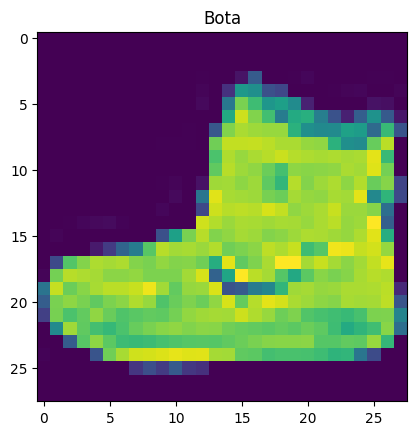

In [ ]:
plt.imshow(train_imgs[0])
plt.title(classes_names[train_labels[0]])

### !!!   DICA   !!!
> Normalização dos pixels da imagem
> de 0-255 para valores de 0-1

**Motivo:** Valores menores fazem com que a rede tenha uma convergência mais eficiente durante o treinamento

In [ ]:
train_imgs = train_imgs/255
test_imgs = test_imgs/255

## Criando o nosso modelo de rede neural

### Importando do keras

In [ ]:
from tensorflow.keras import layers, models

In [62]:
# Declaração do modelo

model = models.Sequential(
    [
        # Camada de compressão para vetor de 784 números
        layers.Flatten(input_shape=(28,28)),

        # Camadas Intermediárias
        layers.Dense(512, activation=tensorflow.nn.relu),
        layers.Dropout(0.2), # camada de dormência\

        #Camada de saida
        layers.Dense(10, activation=tensorflow.nn.softmax )
    ]
)

# Compilação do modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] # adicionar métrica para vizulizar no gráfico
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Treinando nosso modelo

In [63]:
train_stats = model.fit(train_imgs,
          train_labels,
          epochs=2,
          batch_size=32,
          validation_split=0.2
          )

Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8148 - loss: 0.5139 - val_accuracy: 0.8541 - val_loss: 0.4111
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8575 - loss: 0.3911 - val_accuracy: 0.8596 - val_loss: 0.3864


### Testando com as nossas imagens

In [64]:
# Fazendo predição para todo o conjunto de teste
predict_imgs = model.predict(test_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [65]:
# Importando numpy para vizualizar a maior probabilidade
import numpy as np

# Printando a predição do modelo com relação a uma imagem
print(np.argmax(predict_imgs[0])) # mude '0' em relação a posição da imagem que você deseja vizulizar a predição

# Verificação com rotulo real
print(f"Predição do modelo:{classes_names[np.argmax(predict_imgs[0])]}") # mude '0' em relação a posição da imagem que você deseja vizulizar a predição
print(f"Valor real:{classes_names[test_labels[0]]}") # mude '0' em relação a posição da imagem que você deseja vizulizar o valor real

9
Predição do modelo:Bota
Valor real:Bota


## Avaliação do modelo

In [66]:
test_loss, test_accuracy = model.evaluate(test_imgs, test_labels)

print(f"Acurácia no conjunto de teste: {test_accuracy}")
print(f"Perda no conjunto de teste: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8516 - loss: 0.4118
Acurácia no conjunto de teste: 0.8515999913215637
Perda no conjunto de teste: 0.4117743670940399


Printando gráfico de acurácia do modelo

In [ ]:
plt.plot(train_stats.history['accuracy'])
plt.plot(train_stats.history['val_accuracy'])
plt.title('Acurácia por época')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.show()

Printando gráfico de loss do modelo

In [ ]:
plt.plot(train_stats.history['loss'])
plt.plot(train_stats.history['val_loss'])
plt.title('Perda por época')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend(['Treino', 'Validação'])
plt.show()

## Analisando Overfitting e Underfitting

- **underfitting:** A linha de perda (loss) fica alta e não desce muito, e a acurácia (accuracy) fica baixa desde o início e não sobe.
- **overfitting:** A linha de loss de treino continua caindo em direção a zero, e a acurácia de treino vai para 99%. Porém, a linha de val_loss (validação) para de cair e começa a subir, e a val_accuracy estagna ou piora.

## Salvando modelo

In [ ]:
from tensorflow.keras.models import load_model

model.save('model_aula_2.h5')
modelo_salvo = load_model('model_aula_2.h5', custom_objects={'softmax_v2': tensorflow.nn.softmax})

## Fazendo predição com modelo de load

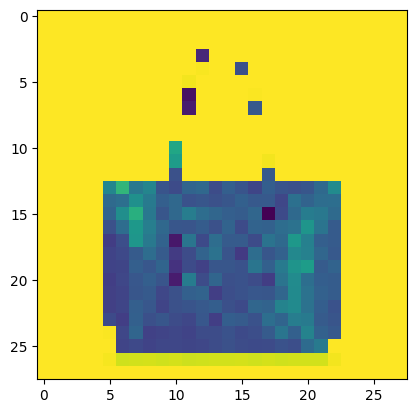

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Resultado da predição: Bolsa


In [70]:
img_url = "https://lepostiche.vtexassets.com/arquivos/ids/1233318/image.jpg?v=639034854708900000"
# Dando load na imagem para o keras salvar internamente
img_path = tensorflow.keras.utils.get_file(origin=img_url)

# carregando imagem e fazendo o rescale para 28x28
# como usamos o dataset MNIS é importante usar o color_mode grayscale
img = tensorflow.keras.utils.load_img(
    img_path,
    target_size=(28, 28),
    color_mode="grayscale"
)

# plotando a nossa imagem para vizualização
plot = plt.imshow(img)
plt.show()

# Convertendo a imagem para um array NumPy
img_array = tensorflow.keras.utils.img_to_array(img)

# Adicionando a dimensão do batch (formato final: [1, 28, 28, 1] ou [1, 28, 28, 3])
img_array = np.expand_dims(img_array, axis=0)

# Normalizando como os nossos dados padrões
img_array = img_array / 255.0

# Fazendo o predict
predict = modelo_salvo.predict(img_array)

predict = classes_names[np.argmax(predict)]

print("Resultado da predição:", predict)

Tarefa: 15 min para tentar arrumar o modelo ou achar uma imagem que funcione

## Vendo o sumário do modelo

In [71]:
summary_model = model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

## Vizualizando pesos e vieses

In [94]:
weights_dense = model.layers[1].get_weights()[0]
bias_dense = model.layers[1].get_weights()[1]

## Colocando Pesos na mão

In [96]:
# Pesos como ZERO

print(weights_dense.shape)
zero_weights_layer = np.zeros((784, 512))
zero_weights_layer
# weights_dense = model.layers[1].set_weights([zero_weights_layer,bias_dense])

# Treinar dnv mas com os pesos zerados
# Inicializa com zero e mata o mata a não-lineariedade



# Pesos com Valores Aleatórios
random_weights_layer = np.random.rand(784, 512)
random_weights_layer
# weights_dense = model.layers[1].set_weights([random_weights_layer,bias_dense])

# Treinar dnv mas com os pesos aleatorios
# Mata a rede, o problema de gradiente perdido aparece

(784, 512)


array([[0.13443843, 0.29299489, 0.35937774, ..., 0.8635896 , 0.87222014,
        0.08279734],
       [0.48986223, 0.033377  , 0.02173865, ..., 0.44023024, 0.67830098,
        0.54372458],
       [0.57672752, 0.06272723, 0.25224016, ..., 0.59436905, 0.37928385,
        0.87454175],
       ...,
       [0.33132445, 0.55071244, 0.03794733, ..., 0.27566014, 0.20152805,
        0.40723341],
       [0.69562325, 0.26200749, 0.52576937, ..., 0.09965624, 0.66622674,
        0.4233539 ],
       [0.76354603, 0.93349197, 0.95242726, ..., 0.72177696, 0.75402606,
        0.22473258]])